In [1]:
import math
import torch 
import torch.nn as nn
import numpy as np 
import pandas as pd 
import sys
import torch.nn.functional as F
import tqdm
from pathlib import Path
import json
from transformers import AutoConfig, AutoTokenizer, AutoModel
from Bio import SeqIO 
import bioframe as bf

/workspace-SR003.nfs2/aspeedok/aspeedok/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
sys.path.append("/workspace-SR003.nfs2/aspeedok/GENA_LM/")

In [3]:
import logging
from pathlib import Path

import torch
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from transformers import AutoConfig, AutoTokenizer

from lm_experiments_tools.utils import get_cls_by_name

def load_model(experiment_config_path, device, ckpt = "model_best"):
    experiment_config_path = Path(experiment_config_path).expanduser().absolute()

    with initialize_config_dir(str(experiment_config_path.parent), version_base=None):
        experiment_config = compose(config_name=experiment_config_path.name,
            overrides=["args_params.model_path=null"])
        
    backbone_cls = get_cls_by_name(experiment_config['args_params']['backbone_cls'])
    rmt_cls =  get_cls_by_name(experiment_config['args_params']['model_cls'])

    #backbone model
    if "model_kwargs" in experiment_config:
        model_kwargs = instantiate(experiment_config["model_kwargs"]) 
    else:
        raise KeyError("Missing required section 'model_kwargs' in experiment_config")

    #плохо
    model_cfg = AutoConfig.from_pretrained("/workspace-SR003.nfs2/aspeedok/GENA_LM/data/configs/L24-H1024-A16-V32k-preln-lastln.json")
    # model_cfg = AutoConfig.from_pretrained(str(experiment_config_path.parent) + "/config.json")
    if "config" in model_kwargs:
        for k,v in model_kwargs["config"].items():
            model_cfg.__setattr__(k,v)
        model_kwargs["config"] = model_cfg

    backbone = backbone_cls(**model_kwargs)

    #RMT model
    #плохо
    rmt_kwargs = {k: v for k, v in experiment_config['args_params'].items() if k != 'model_cls' and k != 'backbone_cls'}
    tokenizer = AutoTokenizer.from_pretrained(experiment_config['shared_dataset_params']['gen_tokenizer'])
    rmt_kwargs['tokenizer'] = tokenizer

    model = rmt_cls(base_model=backbone, **rmt_kwargs)

    #Loading checkpoint
    ckpt_path = experiment_config_path.parent / ckpt / "pytorch_model.bin"
    checkpoint = torch.load(ckpt_path, map_location="cpu")
    missing_keys, unexpected_keys = model.load_state_dict(checkpoint, strict=True)
    if missing_keys:
        logging.warning(f"Missing keys in state_dict: {missing_keys}")
    if unexpected_keys:
        logging.warning(f"Unexpected keys in state_dict: {unexpected_keys}")
    print("RMT model loaded successfully.")

    model = model.to(device).eval()
    return model, tokenizer

In [4]:
from genalg import *
from utils import pad_to_length, cut_seq, calc_ident

# Параметры

In [5]:
experiment_config_path = "/home/jovyan/shares/SR003.nfs2/aspeedok/runs/expression/qnorm/multispices_min_13/20250929-014808/experiment_config.yaml"
seq = 'ATGCATCG'
device = "cuda:0"
text_data_path = "/home/jovyan/shares/SR003.nfs2/aspeedok/GENA_LM/downstream_tasks/expression_prediction/datasets/data/file_mappings/full_combined_file_mappings_embeddings.pkl"
selected_keys = ["McKellar2021_Endothelial_Artery", "McKellar2021_Endothelial_Capillary", "McKellar2021_Endothelial_Vein"]
REQUIRED_LENGTH = 3000

In [6]:
TARGETS = ['McKellar2021_Endothelial_Artery']
OFF_TARGETS = ["McKellar2021_Endothelial_Capillary", "McKellar2021_Endothelial_Vein"]

In [7]:
maxes = {"McKellar2021_Endothelial_Artery": 1, "McKellar2021_Endothelial_Capillary": 1, "McKellar2021_Endothelial_Vein": 1}
criterion = MaxCriterion(maxes=maxes, targets=TARGETS, off_targets=OFF_TARGETS)

# Основная часть

In [8]:
model, tokenizer = load_model(experiment_config_path, device)

RMT model loaded successfully.


In [9]:
initial_pool = pd.read_csv('/home/jovyan/shares/SR003.nfs2/aspeedok/GENA_LM/downstream_tasks/expression_prediction/intervals/human.valid.forward.csv', sep = '\t')
genome = SeqIO.to_dict(SeqIO.parse("/home/jovyan/shares/SR003.nfs2/aspeedok/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/hg38.fa", format="fasta"))

In [10]:
genome_pool_sc = []
for _, row in tqdm.tqdm(initial_pool.iterrows(), total=initial_pool.shape[0]):
    seq = genome[row.chrom][row.TSS - 1500:row.TSS + 1500].upper()
    seq = str(seq.seq)
    sc = get_score(model=model, 
                   tokenizer=tokenizer, 
                   seq=seq,
                   criterion=criterion, 
                   device=device, 
                   label='genome',
                   selected_keys = selected_keys,
                   text_data_path = text_data_path,)

    genome_pool_sc.append(sc)


  0%|          | 0/1548 [00:00<?, ?it/s]/workspace-SR003.nfs2/aspeedok/aspeedok/lib/python3.9/site-packages/transformers/modeling_utils.py:1060: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 1548/1548 [02:12<00:00, 11.66it/s]


In [11]:
genome_pool_sc[:5]

[ScoredSeq(seq='TGGTTACTACCTAGGCCTATAAATCACAGAATTCAACCTAAAGCCTTAAAAATAAACTTAAACATTAGGTCAGAGTTATATATAAATTATAGGACCCTGAGTCGTGTAATCCTGATGAAGTAAAATCTAAAAGTACATTATTTCAAGAAAGAGAAAATTATGTGATTGGCTAAGACTAGGAAACCCCAACATAAGGTCATCACCTCAAAACTTACATTTTAAATTATTTTGTGGTAAGTAGGGAGGTCAGCTATGCAATGAATCATCTTGGAATCATCCTTGATCTAACATCAGCATATCTGAGACAATGAGAATTCTTTCTCTTTGGGAACCGATAAGATTATTGTAACAGCCTACACACACACACTGACACACACGATCAGTCTGATGGCAATAATATTTTTGTTCTATATTTTTGCCAATGCTTTTGAAATTATTATCAGATTTAAATGTTTTCAGGTGTTTGAAATACTTAAAATGCATTTTATTAGTTTCATAAGACTAATCTATTTACTTTATGAAATATATTTCAGTATTCACAGTTAATTTTAACTGATAGTTTTGTAAGTTGATTTTTAGGGATTTTAAGAGTATAAGAGAATCTTACAGACTTGTGATTTTAGTTTAGCAGGATTTTATTAATTTAATAATCAGACCTTAAAATTTAAGAAAAACTAATCTATTCACTACATACTTAACATGTTTAATAATTAAACTATTGTTTACTGAAATTACAAGTCAAATTCATTGACCATAAATCAAGATCAAAGTGTTTACGAAAGGTCCTCCATGATGTACAAAAAGCCTTTGGCAGTAAAGAGCTTTTACCAGATCTGAATCATGAAGGGGAGTTTACATTTCCTTATAACATTTTCTTTAAAGGATACAGGAATGTAGAATATGTTTTTGAAAAGTAATTCTATAAAAAGTAATGAAAACAGATTTTTTGTTCTTAAAGGAATATTTGTCAATTATTTGGAAAAT

In [ ]:
initial_pool = pd.read_table("promoters.bed")
genome = SeqIO.to_dict(SeqIO.parse("/mnt/10tb/home/penzar/hg38.fa", format="fasta"))

tensor([0.0007])
tensor(0.6473)


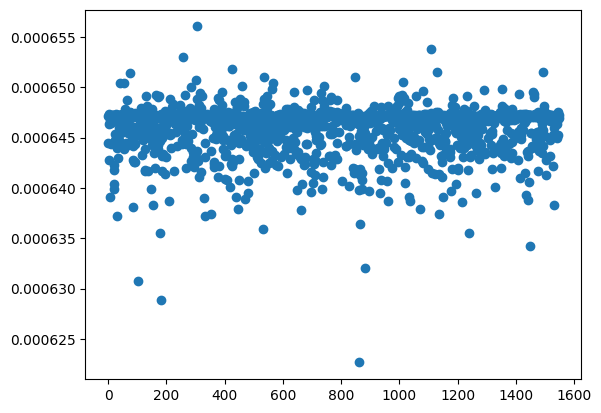

In [12]:
# check if initial scores result in reasonable probabilities
genome_probs = get_probs(torch.FloatTensor([x.score for x in genome_pool_sc]), T=10)
print(torch.sort(genome_probs).values[-1:])
print(torch.sort(genome_probs).values[-1000:].sum())
import matplotlib.pyplot as plt
plt.scatter(np.arange(0, genome_probs.shape[0]), genome_probs.numpy())
plt.show()

In [ ]:
N_GENS = 10
N_ITERS = 100_000
POPULATION_SIZE = 100
REPORT_EACH = 100
REMOVE_PARENTS_EACH = 100
MAX_TEMPERATURE = 10
MIN_TEMPERATURE = 0.010
MEAN_MOTIF_LENGTH = 12

ADD_NEXT_PORTION = 100

In [16]:
N_GENS = 1
N_ITERS = 100_0
POPULATION_SIZE = 100
REPORT_EACH = 100
REMOVE_PARENTS_EACH = 100
MAX_TEMPERATURE = 10
MIN_TEMPERATURE = 0.010
MEAN_MOTIF_LENGTH = 12

ADD_NEXT_PORTION = 100

END_SEQS = []

temps = torch.linspace(MAX_TEMPERATURE, MIN_TEMPERATURE, steps=N_ITERS)



for K in range(N_GENS):

    STORAGE = {}
    MUTATED = {}
    
    cur_genome_pool = genome_pool_sc
    
    genome_probs = get_probs(torch.FloatTensor([x.score for x in cur_genome_pool]), T=temps[0])
    take_ind = torch.multinomial(genome_probs , 100).tolist()
    taken = [cur_genome_pool[i] for i in take_ind]
    not_take = set(range(0, len(cur_genome_pool))) - set(take_ind)
    cur_genome_pool = [cur_genome_pool[i] for i in not_take ]
    
                   
    population =  taken
    
    for p in population:
        STORAGE[p.seq] = p.score
    
    
    losses = []
    best_par = min(population, key=lambda p: p.score)

    keep = True
    for i in tqdm.tqdm(range(N_ITERS)):
        
        losses.append(min(p.score for p in population))
        if i % REPORT_EACH == 0:
            print(losses[-1], calc_ident(genome_pool_sc[0].seq, best_par.seq), best_par.dt)
            
        par1, par2 = select_parents(population, T=temps[i])
        
        child = mix(par1, par2)
        if child not in STORAGE:
            child = get_score(model=model, 
                   tokenizer=tokenizer, 
                   seq=seq,
                   criterion=criterion, 
                   device=device, 
                   label='mix',
                   selected_keys = selected_keys,
                   text_data_path = text_data_path,)
            STORAGE[child.seq] = child.score
            population.append(child)#
    
        par1, par2 = select_parents(population,  T=temps[i])
        
        child = cross(par1, par2, mean_length=MEAN_MOTIF_LENGTH)
        if child not in STORAGE:
            child = get_score(model=model, 
                   tokenizer=tokenizer, 
                   seq=seq,
                   criterion=criterion, 
                   device=device, 
                   label='cross',
                   selected_keys = selected_keys, 
                   text_data_path = text_data_path)
            STORAGE[child.seq] = child.score
            population.append(child)
            
        best_par = min(population, key=lambda p: p.score) # no torch
    
        if best_par.seq not in MUTATED:
            MUTATED[best_par.seq] = get_default_mut_mask(REQUIRED_LENGTH)
            
        if  len(MUTATED[best_par.seq]) == 0:
            print('END of generation')
            break
            
        mut = single_point_mutate(best_par.seq,  MUTATED[best_par.seq])
        if mut not in STORAGE:
            mut = get_score(model=model, 
                   tokenizer=tokenizer, 
                   seq=seq,
                   criterion=criterion, 
                   device=device, 
                   label='snp',
                   selected_keys = selected_keys,                    text_data_path = text_data_path,)
            STORAGE[mut.seq] = mut.score
            population.append(mut)
    
        if i != 0 and i % REMOVE_PARENTS_EACH == 0:
            population = remove_duplicates(population)
            population = select_lowk_and_soft(population, k=POPULATION_SIZE,  T=temps[i])
    
        if i != 0 and i % ADD_NEXT_PORTION == 0 and len(cur_genome_pool) != 0:
            if len(cur_genome_pool) < 100:
                taken = cur_genome_pool
                cur_genome_pool = []
            else:
                genome_probs = get_probs(torch.FloatTensor([x.score for x in cur_genome_pool]), T=temps[i])
                take_ind = torch.multinomial(genome_probs , 100).tolist()
                taken = [cur_genome_pool[i] for i in take_ind]
                not_take = set(range(0, len(cur_genome_pool))) - set(take_ind)
                cur_genome_pool = [cur_genome_pool[i] for i in not_take ]
            population.extend(taken)
    #if keep:
    best_par = min(population, key=lambda p: p.score)
    END_SEQS.append(best_par)
    print(END_SEQS)

  0%|          | 0/1000 [00:00<?, ?it/s]

-0.038095951080322266 0.23 {'McKellar2021_Endothelial_Artery': 2.7913711071014404, 'McKellar2021_Endothelial_Capillary': 2.735962152481079, 'McKellar2021_Endothelial_Vein': 2.753275156021118}


 10%|█         | 100/1000 [00:22<02:30,  6.00it/s]

-0.038095951080322266 0.23 {'McKellar2021_Endothelial_Artery': 2.7913711071014404, 'McKellar2021_Endothelial_Capillary': 2.735962152481079, 'McKellar2021_Endothelial_Vein': 2.753275156021118}


 20%|██        | 200/1000 [00:47<02:43,  4.89it/s]

...

-0.13449382781982422 0.2673333333333333 {'McKellar2021_Endothelial_Artery': 2.2731735706329346, 'McKellar2021_Endothelial_Capillary': 2.1155519485473633, 'McKellar2021_Endothelial_Vein': 2.1386797428131104}


 90%|█████████ | 903/1000 [03:35<00:09,  9.74it/s]

-0.13449382781982422 0.2673333333333333 {'McKellar2021_Endothelial_Artery': 2.2731735706329346, 'McKellar2021_Endothelial_Capillary': 2.1155519485473633, 'McKellar2021_Endothelial_Vein': 2.1386797428131104}


100%|██████████| 1000/1000 [03:57<00:00,  4.21it/s]

[ScoredSeq(seq='ACCAGTAGAATCAGGGTAGAAACCCCCCACCCTCGTATTTTCAAATGTACCTGAACAAGCATTCACAGCTTCCAACTATTGTGCAATAAACAGCAAAAAAAAAAAAAGTCCTTGAACCAAAATTGTCCTTAGCTGCTCTGCCCTCTAAGATGGGGCATAGTTTACATGGGAGTTGGGGGAGGACTCCATGTTTGCCCCTTCCCCTTGCTGAGATGGCTGGGGGTGGGGGCTGGAAAAAGTTGGATTCAGCAGAATGTAATTTGGAAAACATGGCTCTGGAGCACCATCCCCTCTGGCCCCTGAATCCTCACCAGCTTCCACCCTCTGCTCACCTTGGGCCCTGGATTCCAGCGCCCCCAGGCTCCCAGCTGCCTCCCTGTCTCTGCCCCATGGTCCAGCCTGGAGTTCTGGTCCCTGGTTGTGTCCTGTGGCCCCATTCTCATGCGCCCTTTGCTTCTATTTCTTTACCTATGACTTTATACTGATGTAAAGCGAGTCTTCTCGGTCGCTTCTTGTTCTCTGAGGAATGTTGAATCAGAATCTAAATGGAAAATCTGGGAAGAGATAGAACCTCCCGCGGGAGCCACCCTGCCCTTCCATGTCTAGATCATCTGGGTTCCAACCTCCATCCTCCTCCAATGAGAAGCTTTTGTTCTCTCAAGATTCCAGTGACTTCTCCGAAGCTCTCTTCATCCCTGGCTGTTCCAAGGTGGCCCCATAGTCAAGATTCCTTAAACCCTTGCCCCTTAAAATGTTTGCCTTTCTTACCATGCTGGCTCCAGCCTCTGGTCCCAGGGGTGTGGAGAGTTCTCTCTTACTTCTGGCTGATTTCCAGGAAGGCTAAGAACACTCTCCCCAGGTTATAATGCTGAGCATTTTGGTTCTCTCCAGCCCTGGGTCCCCATGTCAGGACCTACCTTAGTCCAGTCCATGCTCTCCCATGGGCCTGAGAGAAGATTTGAAGTTTCTGGCTTTCCCTCCAAC